In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn (scikit-learn)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('D:/Broadway/Data Science - 2/Car_Sales.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [14]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [15]:
transmission_id = {
    'Manual': 0, 
    'Automatic': 1
}
df['transmission_id'] = df['transmission'].map(transmission_id)

In [16]:
# df

In [17]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'owner_id', 'fuel_id', 'seller_type_id',
       'transmission_id'],
      dtype='object')

In [18]:
features = df[['year', 'km_driven', 'fuel_id', 'seller_type_id', 'transmission_id', 'owner_id']]
target = df['selling_price']

In [19]:
X = features
Y = target

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

In [32]:
# Feature Scaling -> Standard Scaler (Xi-mean/sd)
# mean and stdev (80% training)
scaler = StandardScaler()

In [35]:
# scale X_train
# Fit Transform -> Learning (training -> mean & stdev) + Implement
X_train_scaled = scaler.fit_transform(X_train)

In [39]:
# Transform -> Implement
X_test_scaled = scaler.transform(X_test)

In [21]:
model = LinearRegression()

In [37]:
model.fit(X_train_scaled, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
Y_pred = model.predict(X_test_scaled)

In [44]:
# Slope and Intercept
beta_0 = model.intercept_
beta_1 = model.coef_
print("Intercept:",beta_0)
print("Slope/Coefficient:",beta_1)

Intercept: 501101.3150921638
Slope/Coefficient: [168855.88782871 -27481.85329129 116543.74264288  45882.97862366
 261834.77691376  -9692.47983567]


In [45]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

In [46]:
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 406380.75601196353
R2 Score: 0.4918005460679501


In [62]:
max_val = max(Y_test.max(), Y_pred.max())
min_val = min(Y_test.min(), Y_pred.min())

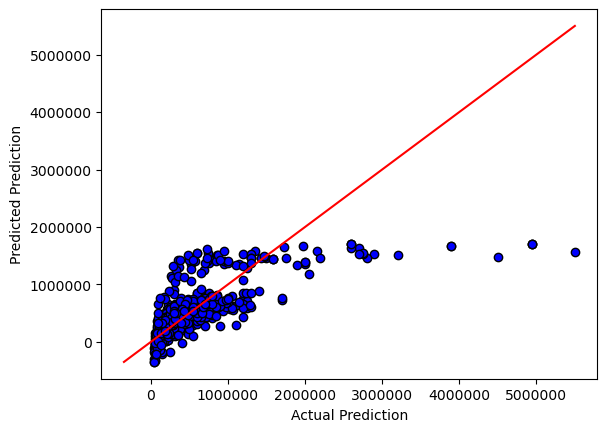

In [67]:
plt.scatter(Y_test, Y_pred, c='blue', edgecolor='black')
# plt.plot([Actual Prediction Point], [Predicted Prediction Point])
plt.plot([max_val, min_val], [max_val, min_val], c='red')
plt.xlabel('Actual Prediction')
plt.ylabel('Predicted Prediction')
plt.ticklabel_format(style='plain', axis='both')

In [81]:
input_data = {
    'year': [2018, 2014, 2015], 
    'km_driven': [25000, 40000, 10000], 
    'fuel_id': [1, 0, 1], 
    'seller_type_id': [0, 1, 2], 
    'transmission_id': [1, 1, 0], 
    'owner_id': [0, 0, 0]
}

In [88]:
X_new = pd.DataFrame(input_data)

In [83]:
X_new_scale = scaler.transform(X_new)

In [84]:
Y_new_pred = model.predict(X_new_scale)

In [85]:
X_new['Predicted_Selling_Price'] = Y_new_pred

In [86]:
X_new['Predicted_Selling_Price'] = X_new['Predicted_Selling_Price'].map("${:,.2f}".format)

In [87]:
X_new

,year,km_driven,fuel_id,seller_type_id,transmission_id,owner_id,Predicted_Selling_Price
0,2018,25000,1,0,1,0,"$1,579,390.28"
1,2014,40000,0,1,1,0,"$1,293,991.53"
2,2015,10000,1,2,0,0,"$789,904.85"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('D:/Broadway/Data Science - 2/insurance.csv')
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.replace({'gender': {'female':0, 'male':1}},inplace=True)

In [9]:
df.replace({'smoker': {'yes':0, 'no':1}},inplace=True)

In [12]:
df.replace({'region': 
            {'southwest': 0, 'southeast': 1, 'northwest':2, 'northeast':3}}, 
           inplace=True)

In [15]:
features = ['age', 'gender', 'bmi', 'children', 'smoker', 'region']
target = 'charges'

In [16]:
X = df[features]
Y = df[target]

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [38]:
scaler = StandardScaler()

In [39]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [40]:
model = LinearRegression()

In [41]:
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
Y_pred = model.predict(X_test_scale)

In [61]:
beta_0 = model.intercept_
beta_1 = model.coef_

print(beta_0)
print(beta_1)

13346.089736364485
[ 3.61610865e+03 -9.39295411e+00  2.02830858e+03  5.16662566e+02
 -9.55714338e+03  3.02387980e+02]


In [43]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

In [44]:
print('Root Mean Squared Error:',rmse)
print('R2 Score / Accuracy:',r2)

Root Mean Squared Error: 5799.587091438359
R2 Score / Accuracy: 0.7833463107364537


In [45]:
max_val = max(Y_test.max(), Y_pred.max())
min_val = min(Y_test.min(), Y_pred.min())

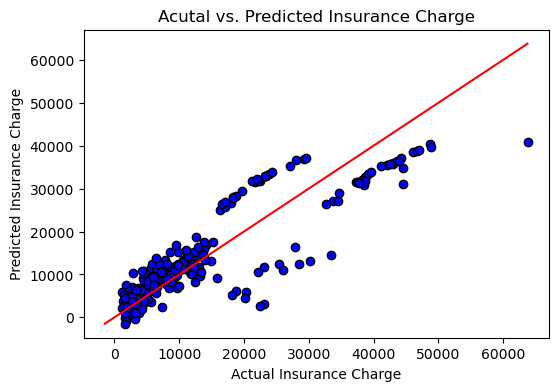

In [51]:
plt.figure(figsize=(6, 4))
plt.scatter(Y_test, Y_pred, color='blue', edgecolor='black')
plt.plot([max_val, min_val], [max_val, min_val], color='red')
plt.xlabel('Actual Insurance Charge')
plt.ylabel('Predicted Insurance Charge')
plt.title('Acutal vs. Predicted Insurance Charge')
plt.show()

# regression plot

<Axes: xlabel='region', ylabel='charges'>

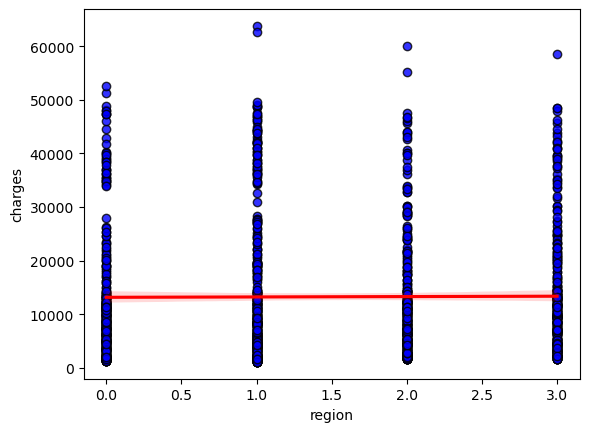

In [59]:
sns.regplot(x='region', y='charges', data=df,
           scatter_kws={'color':'blue', 'edgecolor':'black'}, 
            line_kws={'color':'red'})